<a href="https://colab.research.google.com/github/Elsacred02/Progetto_AML_2025_2026/blob/modifiche-sul-windows-fisso/Codice_progetto_AML_2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import librerie

import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import hashlib
import seaborn as sns

from google.colab import drive
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import preprocess_input
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Monta dataset da google drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/sea_animals"
# os.listdir(DATA_DIR)

Mounted at /content/drive


In [3]:
#DATA_DIR = "sea_dataset_copia"
#os.listdir(DATA_DIR)

In [4]:
# Script per verificare se ci sono immagini duplicate tra le cartelle
# Se due immagini hanno lo stesso hash MD5, allora sono uguali

# Funzione per calcolare hash MD5 di un file
def hash_file(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

# Dizionario per raccogliere hash
hashes = defaultdict(list)

# Esplorazione delle directory
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            file_hash = hash_file(file_path)
            hashes[file_hash].append(file_path)
        except Exception as e:
            print(f"Errore leggendo {file_path}: {e}")

# Stampa dei duplicati
print("Duplicati trovati:")
for file_list in hashes.values():
    if len(file_list) > 1:
        print(" - " + "\n   ".join(file_list))
        print()


Duplicati trovati:


In [5]:
# Le immagini sono tutte di dimensione 300 x N o N x 300 con N valore variabile tra le immagini ed N < 300
# Troviamo N minimo e massimo per immagini orizzontali e verticali

dimensions = {
    "min_vertical" : -1,
    "min_horizontal" : -1,
    "max_vertical" : -1,
    "max_horizontal" : -1,
    "biggest_vertical" : None,
    "biggest_horizontal" : None,
    "removed_images" : 0
}

# Esploro le directory per verificare se ci sono immagini che non rispettano le dimensioni prefissate, intanto salvo anche i valori estremali che trovo
for directory in os.listdir(DATA_DIR):
    for image in os.listdir(os.path.join(DATA_DIR, directory)):
        img = tf.keras.preprocessing.image.load_img(os.path.join(DATA_DIR, directory, image))

        width, height = img.size

        if width > height:
            # L'immagine è orizzontale
            if height > 300:
                dimensions["removed_images"] += 1
                os.remove(os.path.join(DATA_DIR, directory, image))
            elif dimensions["min_horizontal"] == -1 or height < dimensions["min_horizontal"]:
                dimensions["min_horizontal"] = height
            elif dimensions["max_horizontal"] == -1 or height > dimensions["max_horizontal"]:
                dimensions["max_horizontal"] = height
                dimensions["biggest_horizontal"] = os.path.join(directory, image)
        else:
            # L'immagine è verticale
            if width > 300:
                dimensions["removed_images"] += 1
                os.remove(os.path.join(DATA_DIR, directory, image))
            elif dimensions["min_vertical"] == -1 or width < dimensions["min_vertical"]:
                dimensions["min_vertical"] = width
            elif dimensions["max_vertical"] == -1 or width > dimensions["max_vertical"]:
                dimensions["max_vertical"] = width
                dimensions["biggest_vertical"] = os.path.join(directory, image)

print(dimensions)

{'min_vertical': 131, 'min_horizontal': 66, 'max_vertical': 300, 'max_horizontal': 299, 'biggest_vertical': 'Sea Urchins/30905610620_bbfaf7a558_o.jpg', 'biggest_horizontal': 'Seahorse/5120505560_0617580092_o.jpg', 'removed_images': 0}


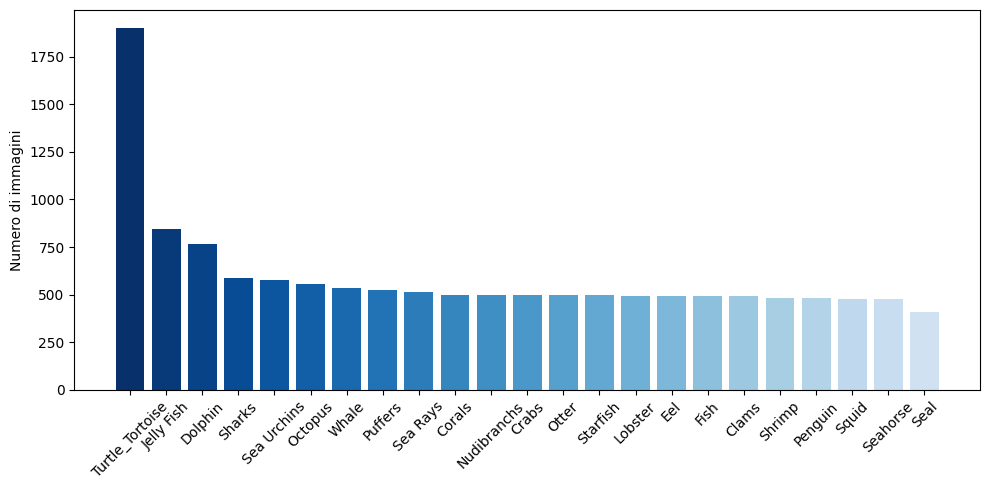

In [6]:
# Controllo bilanciamento dataset
# TBD : nella relazione la tabella andrà sotto la voce "Distribuzione immagini per classe"

# Creo dizionario vuoto
dict_targets_NElements = {}

# Popola il dizionario con le coppie (target, numero di immagini)
for directory in os.listdir(DATA_DIR):
    dict_targets_NElements[directory] = len(os.listdir(os.path.join(DATA_DIR, directory)))

# Ordina il dizionario in modo decrescente
dict_targets_NElements = dict(sorted(dict_targets_NElements.items(), key=lambda x: x[1], reverse=True))

# Crea palette di colori sulla base del numero di elementi del dizionario
colors = plt.cm.Blues(np.linspace(1, 0.2, len(dict_targets_NElements)))

# Grafico della distribuzione immagini per classe
plt.figure(figsize=(10, 5))
plt.bar(dict_targets_NElements.keys(), dict_targets_NElements.values(), color=colors)
plt.xticks(rotation=45)
plt.ylabel("Numero di immagini")
plt.tight_layout()
plt.show()

In [7]:
# Calcolo i class weigths che serviranno al modello per gestire il dataset sbilanciato

# Il numero di classi è pari alla lunghezza del dizionario
num_classes = len(dict_targets_NElements)
print(f"Numero di classi: {num_classes}")

# Raccolgo tutte le etichette del training set
all_labels = []
class_names_ordered = sorted(dict_targets_NElements.keys())

for idx, class_name in enumerate(class_names_ordered):
    num_samples = dict_targets_NElements[class_name]
    all_labels.extend([idx] * num_samples)

# Calcolo i pesi usando la formula 'balanced': n_samples / (n_classes * n_samples_per_class)
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.arange(num_classes),
    y=all_labels
)

# Converto in dizionario {indice_classe: peso}
class_weights = dict(enumerate(class_weights_array))

print("\nClass Weights calcolati:")
for class_idx, class_name in enumerate(class_names_ordered):
    print(f"  {class_name}: {class_weights[class_idx]:.4f}")

Numero di classi: 23

Class Weights calcolati:
  Clams: 1.2017
  Corals: 1.1849
  Crabs: 1.1873
  Dolphin: 0.7699
  Eel: 1.1969
  Fish: 1.1969
  Jelly Fish: 0.7005
  Lobster: 1.1945
  Nudibranchs: 1.1849
  Octopus: 1.0596
  Otter: 1.1873
  Penguin: 1.2292
  Puffers: 1.1241
  Sea Rays: 1.1526
  Sea Urchins: 1.0265
  Seahorse: 1.2395
  Seal: 1.4386
  Sharks: 1.0107
  Shrimp: 1.2267
  Squid: 1.2369
  Starfish: 1.1897
  Turtle_Tortoise: 0.3112
  Whale: 1.1072


In [8]:
# Effettuo la suddivisione del dataset

# 80% train, 10% validation, 10% test
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

# val_test_ds contiene sia i dati di validation che di test
val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

# Voglio separare dati di validation e test in due dataset distinti
# Calcolo il numero di batch e le uso per dividere la seconda porzione del dataset
val_test_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_test_batches // 2)
test_ds = val_test_ds.skip(val_test_batches // 2)

Found 13599 files belonging to 23 classes.
Using 10880 files for training.
Found 13599 files belonging to 23 classes.
Using 2719 files for validation.


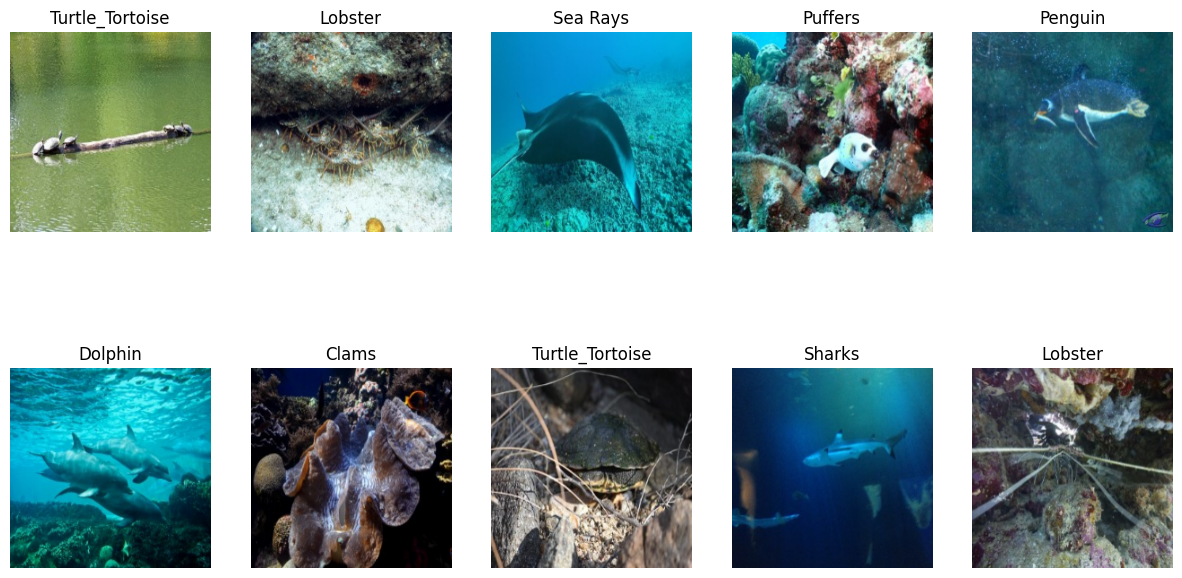

In [9]:
# Stampa a schermo i primi 10 elementi del dataset di training
images, labels = next(iter(train_ds))

class_names = train_ds.class_names

plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

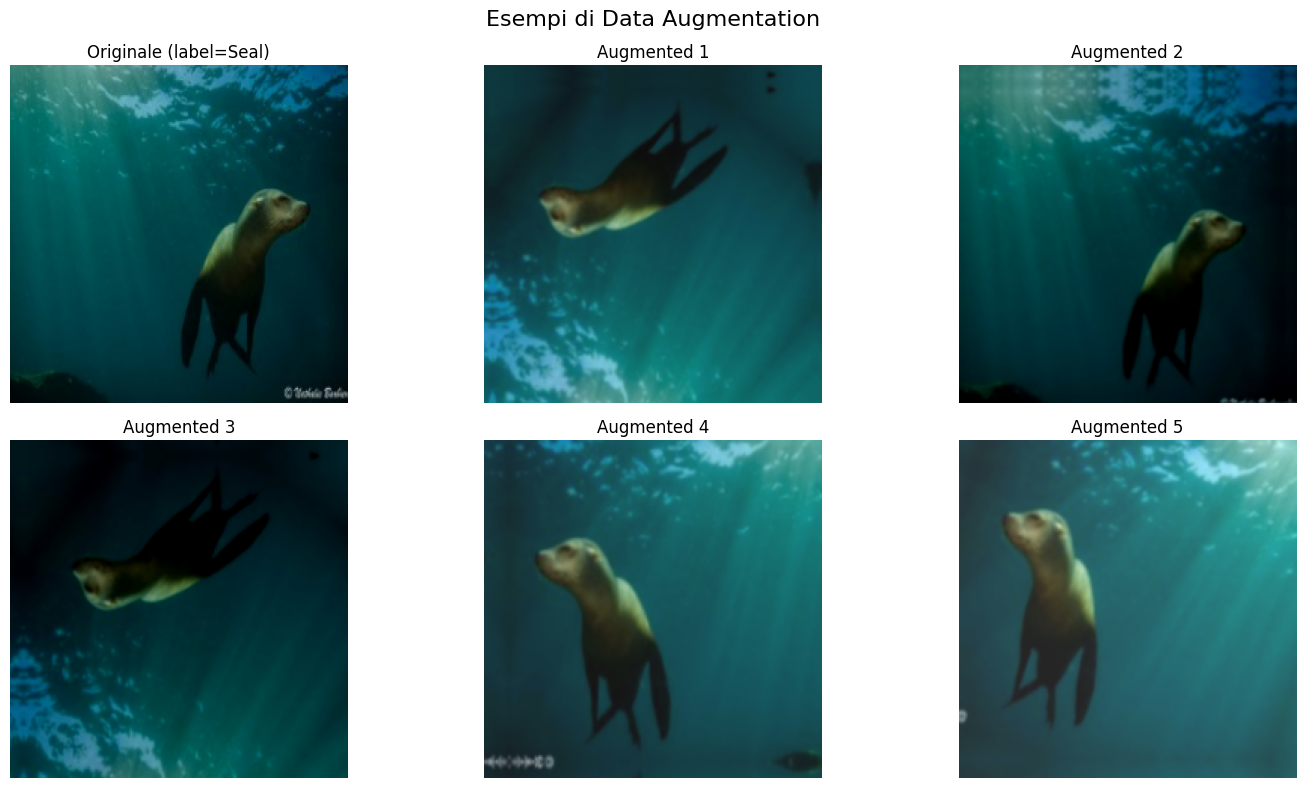

In [10]:
# Questo script serve a trasformare l'input per adattarlo a quello della rete che vogliamo utilizzare
train_ds_EN = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_EN   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_EN  = test_ds.map(lambda x, y: (preprocess_input(x), y))

# Predispongo una serie di operazioni di Data Augumentation che voglio utilizzare solo in fase di training
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomFlip("vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.15),
])

# Stampo a schermo alcuni esempi di Data Augumentation
# I dati sono gia' suddivisi in batch, quindi ne prendo uno (tensore di dimensione 32 x 224 x 224 x 3)
for images, labels in train_ds.take(1):
    batch_images = images
    batch_labels = labels

# Estraggo la prima immagine del batch
original_image = batch_images[0]
label = batch_labels[0]

# Questo script serve per ricostruire l'immagine
original_image = tf.clip_by_value(original_image, 0, 255)
original_image = tf.cast(original_image, tf.uint8)

# Questo comando permette di creare un batch virtuale di dimensione 1 x 224 x 224 x 3
image_batch = tf.expand_dims(original_image, axis=0)

# Creo il grafico
plt.figure(figsize=(15, 8))

# In alto a sinistra metto l'immagine originale
plt.subplot(2, 3, 1)
plt.imshow(original_image)
plt.title(f"Originale (label={class_names_ordered[label]})")
plt.axis("off")

# Produco 5 immagini con Data Augumentation
for i in range(1, 6):
    augmented = data_augmentation(image_batch, training=True)
    aug_img = tf.cast(
        tf.clip_by_value(augmented[0], 0, 255), tf.uint8
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(aug_img)
    plt.title(f"Augmented {i}")
    plt.axis("off")

plt.suptitle("Esempi di Data Augmentation", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
# In questa fase voglio fare solo transfer learning (ossia addestro solo il nuovo classificatore)

# Include_top = false elimina la parte del classificatore originale
base_model = tf.keras.applications.EfficientNetB0(
    include_top = False,
    weights = "imagenet",
    input_shape = (224, 224, 3)
)

# Impedisco che la porzione convoluzionale del modello base possa essere ulteriormente addestrato (è congelato)
base_model.trainable = False

# Creo il nuovo classificatore e lo "aggancio alla rete"
inputs = tf.keras.Input(shape = (224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training = False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(num_classes, activation = "softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,084,154 (15.58 MB)

 Trainable params: 32,023 (125.09 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [12]:
# Avvio l'addestramento con transfer learning

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce LR on Plateau per ridurre il learning rate automaticamente
reduce_lr_phase1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_1 = model.fit(
    train_ds_EN,
    validation_data=val_ds_EN,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_phase1, reduce_lr_phase1]
)

Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 64s 148ms/step - accuracy: 0.4638 - loss: 2.0695 - val_accuracy: 0.7857 - val_loss: 0.7142 - learning_rate: 0.0010
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 142ms/step - accuracy: 0.6644 - loss: 1.1821 - val_accuracy: 0.7924 - val_loss: 0.6864 - learning_rate: 0.0010
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 47s 139ms/step - accuracy: 0.7035 - loss: 1.0719 - val_accuracy: 0.7917 - val_loss: 0.6780 - learning_rate: 0.0010
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - accuracy: 0.7185 - loss: 1.0092 - val_accuracy: 0.8036 - val_loss: 0.6568 - learning_rate: 0.0010
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - accuracy: 0.7239 - loss: 0.9623 - val_accuracy: 0.8021 - val_loss: 0.6378 - learning_rate: 0.0010
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 141ms/step - accuracy: 0.7379 - loss: 0.9315 - val_accuracy: 0.8036 - val_loss: 0.6493 - learning_rate: 0.0010
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.73

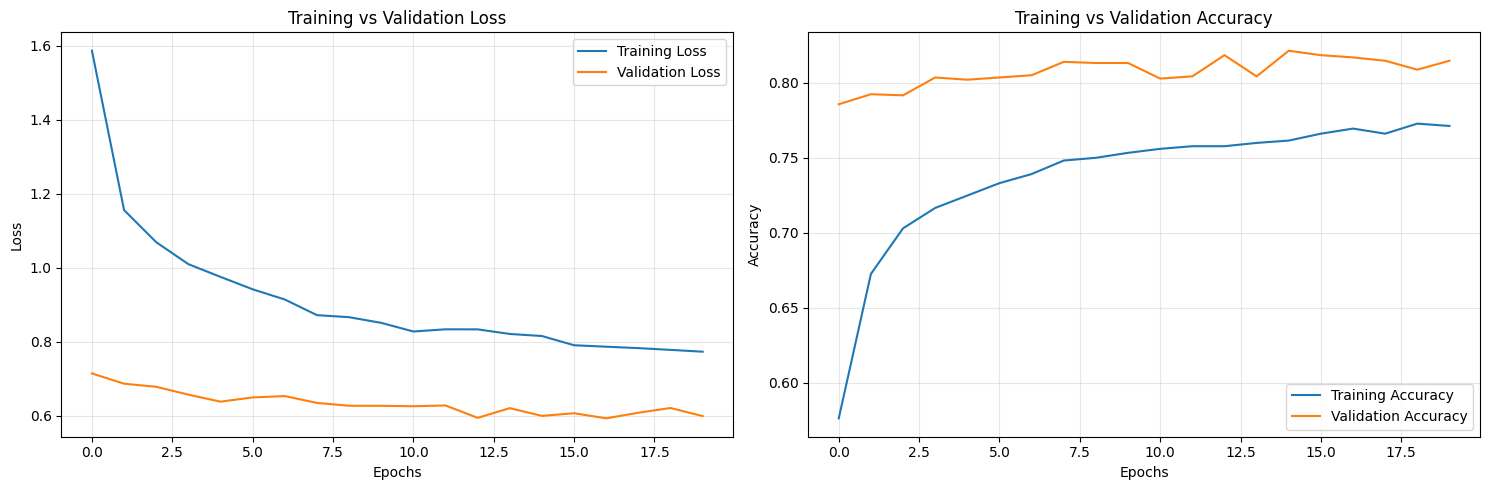

In [13]:
# Stampo in un grafico l'evoluzione dell'accuratezza in training e validazione

history_dict = history_1.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Valutazione del modello sul Test Set
print("--- Valutazione sul Test Set ---")
test_loss, test_accuracy = model.evaluate(test_ds_EN, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Generazione predizioni
print("--- Generazione Predizioni ---")

# Estrazione coerente di y_true e y_pred
y_true = []
y_pred = []

for x_batch, y_batch in test_ds_EN:
    preds = model.predict(x_batch, verbose=0)
    y_pred.append(np.argmax(preds, axis=1))
    y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

print("\n--- Classification Report ---")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
))

--- Valutazione sul Test Set ---
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - accuracy: 0.8456 - loss: 0.5090

Test Loss: 0.5374
Test Accuracy: 0.8415

--- Generazione Predizioni ---

--- Classification Report ---
                 precision    recall  f1-score   support

          Clams      0.703     0.578     0.634        45
         Corals      0.591     0.796     0.678        49
          Crabs      0.923     1.000     0.960        48
        Dolphin      0.951     0.837     0.890        92
            Eel      0.741     0.769     0.755        52
           Fish      0.818     0.692     0.750        52
     Jelly Fish      0.946     0.978     0.961        89
        Lobster      0.703     0.865     0.776        52
    Nudibranchs      0.765     0.750     0.757        52
        Octopus      0.658     0.472     0.549        53
          Otter      0.958     1.000     0.979        46
        Penguin      0.975     0.867     0.918        45
        Puffers      0.769     0.816     0.79

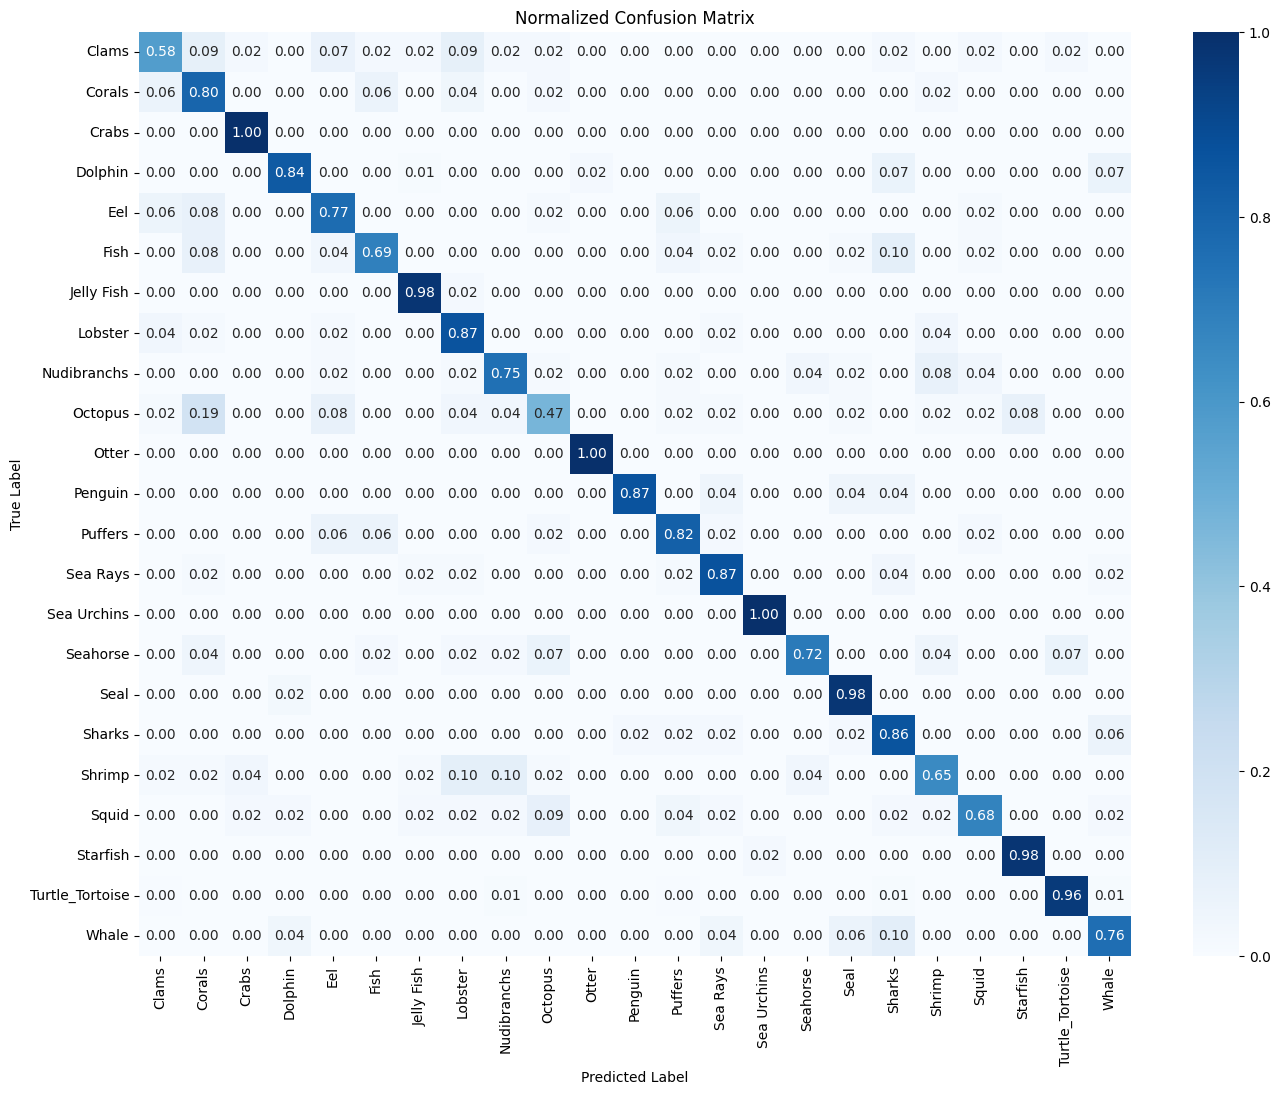

In [15]:
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()

In [16]:
# Scongelo la prima porzione della rete
base_model.trainable = True

# Congelo tutti i layer tranne gli ultimi 15
for layer in base_model.layers[:-15]:
    layer.trainable = False

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,148,202 (15.82 MB)

 Trainable params: 940,231 (3.59 MB)

 Non-trainable params: 3,143,923 (11.99 MB)

 Optimizer params: 64,048 (250.19 KB)

In [17]:
# Continuo l'addestramento
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce LR on Plateau per ridurre il learning rate automaticamente
reduce_lr_phase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history_2 = model.fit(
    train_ds_EN,
    validation_data=val_ds_EN,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_phase2, reduce_lr_phase2]
)

Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 63s 149ms/step - accuracy: 0.6950 - loss: 1.0539 - val_accuracy: 0.8207 - val_loss: 0.6365 - learning_rate: 1.0000e-04
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 142ms/step - accuracy: 0.7523 - loss: 0.8398 - val_accuracy: 0.8244 - val_loss: 0.6212 - learning_rate: 1.0000e-04
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 47s 139ms/step - accuracy: 0.7638 - loss: 0.7959 - val_accuracy: 0.8318 - val_loss: 0.5932 - learning_rate: 1.0000e-04
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 83s 142ms/step - accuracy: 0.7758 - loss: 0.7482 - val_accuracy: 0.8281 - val_loss: 0.6056 - learning_rate: 1.0000e-04
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7839 - loss: 0.7166
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
340/340 ━━━━━━━━━━━━━━━━━━━━ 47s 139ms/step - accuracy: 0.7839 - loss: 0.7166 - val_accuracy: 0.8289 - val_loss: 0.5936 - learning_rate: 1.0000e-04
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 141ms/st

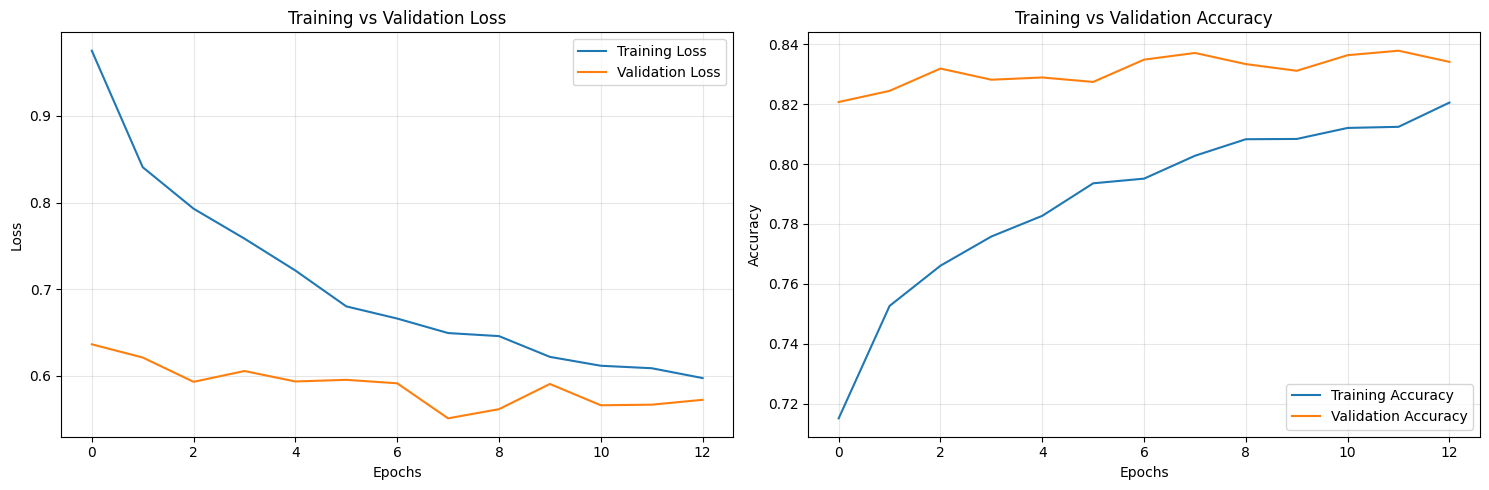

In [18]:
history_dict = history_2.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Valutazione del modello sul Test Set
print("--- Valutazione sul Test Set ---")
test_loss, test_accuracy = model.evaluate(test_ds_EN, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Generazione predizioni
print("--- Generazione Predizioni ---")

# Estrazione coerente di y_true e y_pred
y_true = []
y_pred = []

for x_batch, y_batch in test_ds_EN:
    preds = model.predict(x_batch, verbose=0)
    y_pred.append(np.argmax(preds, axis=1))
    y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

print("\n--- Classification Report ---")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
))


--- Valutazione sul Test Set ---
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.8692 - loss: 0.4975

Test Loss: 0.5289
Test Accuracy: 0.8582

--- Generazione Predizioni ---

--- Classification Report ---
                 precision    recall  f1-score   support

          Clams      0.725     0.659     0.690        44
         Corals      0.617     0.804     0.698        46
          Crabs      0.943     1.000     0.971        50
        Dolphin      0.931     0.880     0.905        92
            Eel      0.736     0.736     0.736        53
           Fish      0.822     0.740     0.779        50
     Jelly Fish      0.969     0.969     0.969        97
        Lobster      0.774     0.872     0.820        47
    Nudibranchs      0.712     0.740     0.725        50
        Octopus      0.675     0.519     0.587        52
          Otter      0.957     1.000     0.978        44
        Penguin      1.000     0.909     0.952        44
        Puffers      0.821     0.868     0.84

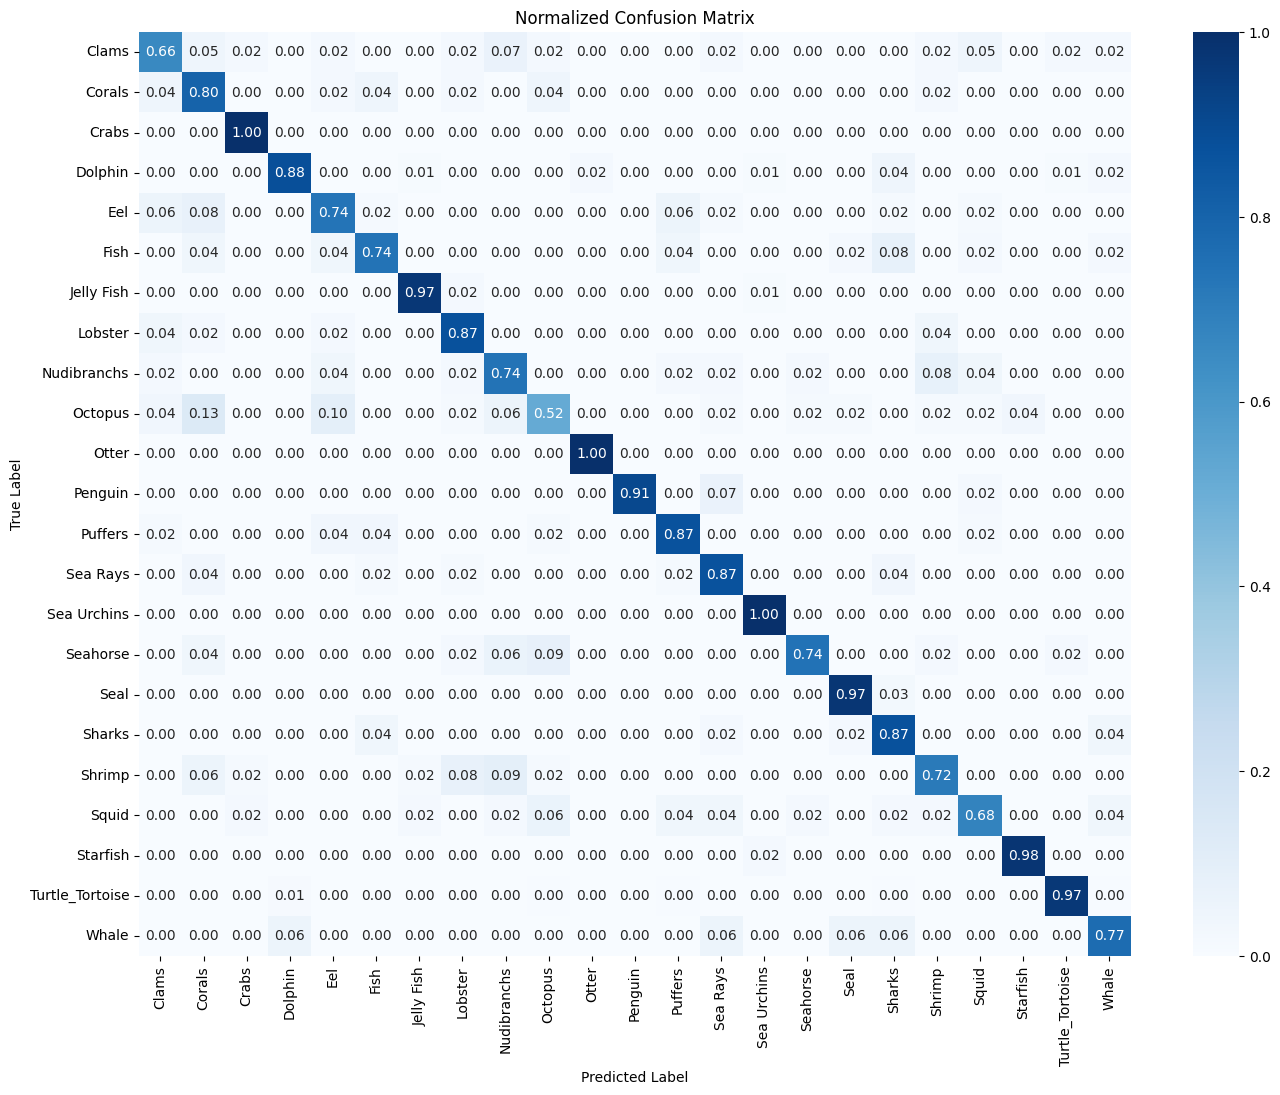

In [20]:
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()